In [6]:
import numpy as np
import pandas as pd
from scipy import stats
import json

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

### NOTEs
- --profile_encoder cnn seems to give hgher fid but so far do not report. 

In [3]:
ls ../experiments/archive/

dcgan_baseline_20260817_231036/  stylegan_baseline_20260819_170800/


,iteration,fid
0,10000,18.249764
1,20000,13.719028
2,30000,18.724583
3,40000,21.187816
4,50000,14.290339
...,...,...
65,660000,15.961264
66,670000,14.757754
67,680000,10.373347
68,690000,10.572365


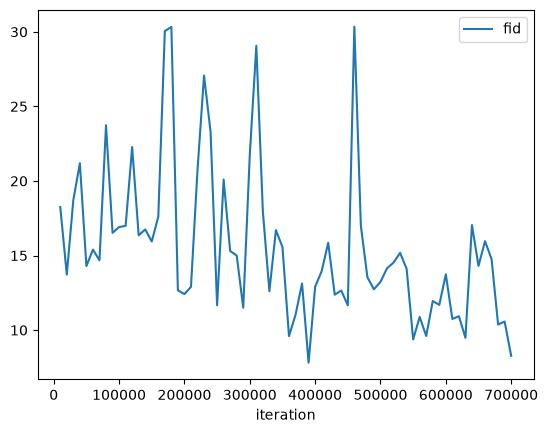

In [7]:
fid_path = "../experiments/archive/stylegan_baseline_20260819_170800/validation_fid.jsonl"
with open(fid_path, encoding="utf-8") as f:
    fids = [
        json.loads(line)
        for line in f
        if line.strip()
    ]
df_fid_all = pd.DataFrame(fids)
df_fid = df_fid_all.query("iteration%10000==0")#because checkpoing is every 10000 
df_fid.plot(x="iteration",y="fid")
display(df_fid)

In [8]:
df_fid.sort_values(['fid'])

,iteration,fid
38,390000,7.813702
69,700000,8.272099
54,550000,9.374662
62,630000,9.477013
35,360000,9.591983
...,...,...
22,230000,27.065344
30,310000,29.064080
16,170000,30.052358
17,180000,30.326650


In [ ]:
checkpoint_path = "~/projects/fcmstylegan/experiments/archive/stylegan_baseline_20260819_170800/checkpoint/390000pt"

In [28]:
ls ~/projects/fcmstylegan/experiments/archive/stylegan_baseline_20260819_170800/sample/390000.jpg

/home/satoshi/projects/fcmstylegan/experiments/archive/stylegan_baseline_20260819_170800/sample/390000.jpg


python evaluate.py \
    --model stylegan \
    --ckpt experiments/archive/stylegan_baseline_20260819_170800/checkpoint/390000.pt \
    --datasplit data/task1_dataset_split.csv \
    --preprocessed_root data/task1_processed \
    --split test \
    --use_mask \
    --seed 123 \
    --save_images_dir experiments/archive/stylegan_baseline_20260819_170800/test_eval_imgs \
    --output experiments/archive/stylegan_baseline_20260819_170800/test_eval_stat.json \
    --per_image_output experiments/archive/stylegan_baseline_20260819_170800/test_eval_imgs.jsonl


python evaluate_saved_crops.py \
    --save_images_dir experiments/archive/stylegan_baseline_20260819_170800/test_eval_imgs \
    --datasplit data/task1_dataset_split.csv \
    --preprocessed_root data/task1_processed \
    --split test \
    --crop_size 70 \
    --output experiments/archive/stylegan_baseline_20260819_170800/test_eval_crop70_stat.json


,value
model,stylegan
checkpoint,/home/satoshi/projects/fcmstylegan/experiments...
split,test
num_samples,34753
seed,123
mask_metrics,True
fid,7.867075
psnr_mean,20.500484
ssim_mean,0.889729
psnr_masked_mean,13.217765


,mean,median,std,min,max,count
psnr,20.5005,20.9667,4.0523,6.2734,30.1206,34753.0000
ssim,0.8897,0.8953,0.0332,0.6281,0.9746,34753.0000
psnr_masked,13.2178,13.4146,1.4055,5.8697,18.1128,34753.0000
ssim_masked,0.0831,0.0739,0.1108,-0.5361,0.6538,34753.0000
lpips,0.1411,0.1333,0.0491,0.0375,0.4988,34753.0000
lpips_crop,0.2445,0.2380,0.0652,0.0758,0.5814,34753.0000


,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_42773,30.12,0.9657,13.13,0.0849,0.3015,0.3500


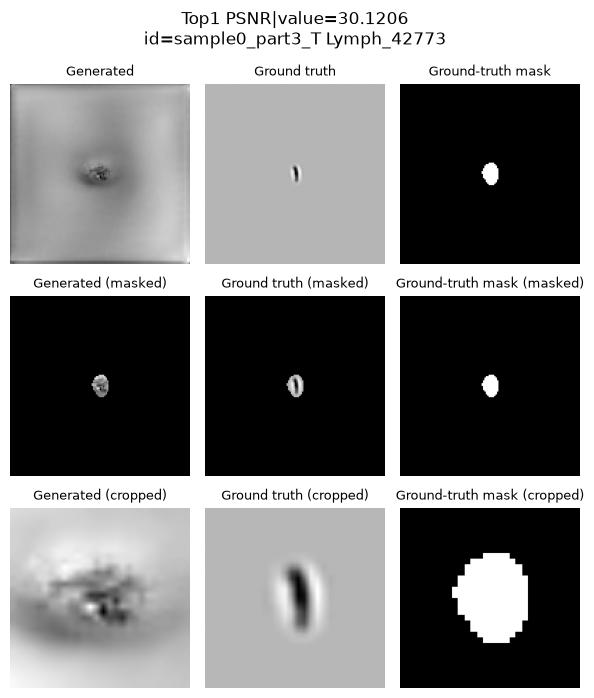

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_Neut_3142,20.97,0.8723,13.74,0.0614,0.1286,0.2810


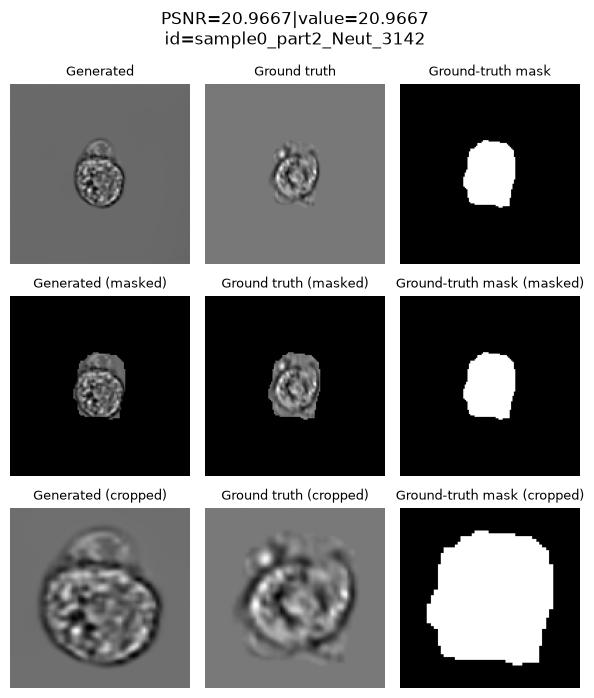

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_B Lymph_30017,6.27,0.6439,5.87,0.0008,0.4731,0.4956


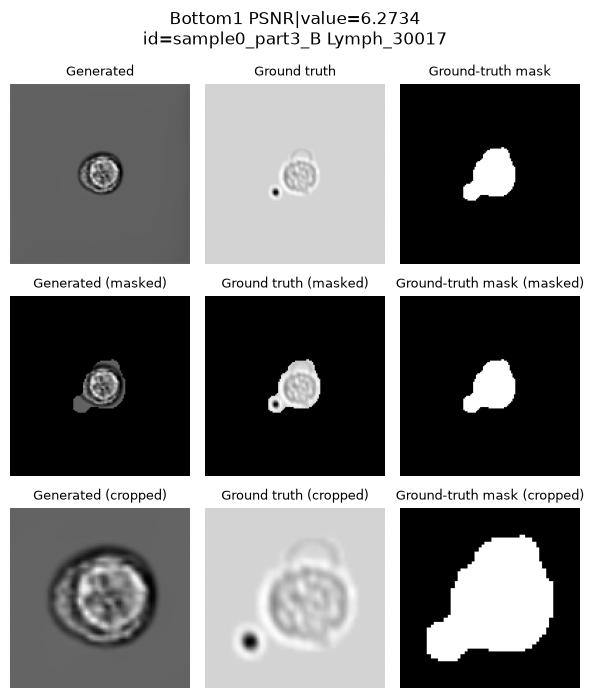

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_B Lymph_36294,29.58,0.9746,16.62,0.6538,0.0529,0.0777


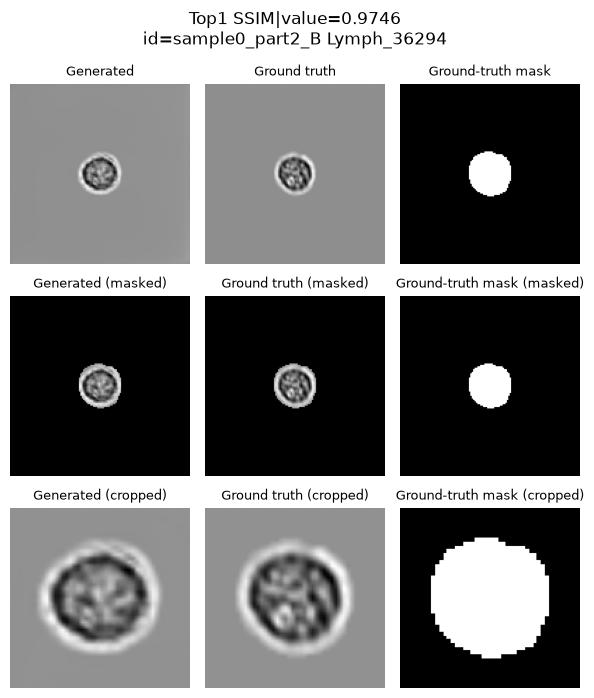

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_Neut_39488,22.53,0.8953,15.02,0.1078,0.1025,0.2071


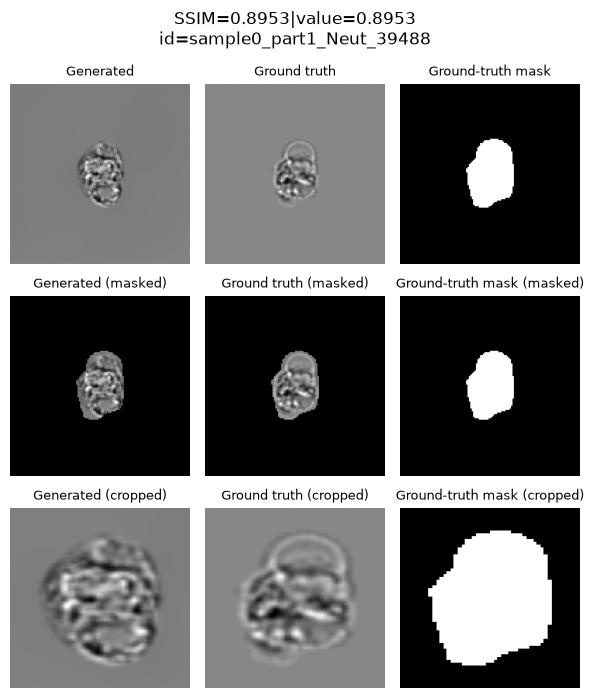

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_4355,9.37,0.6281,9.20,0.1041,0.3508,0.4582


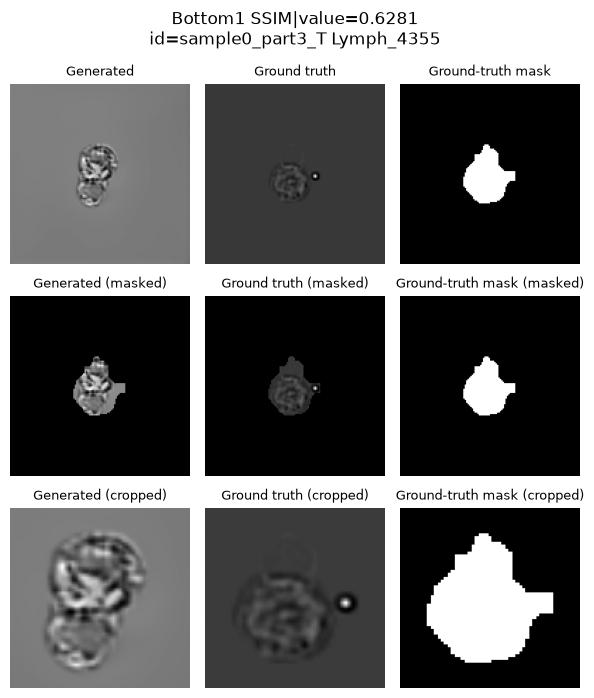

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_Neut_46424,29.18,0.9151,18.11,0.1985,0.1555,0.3292


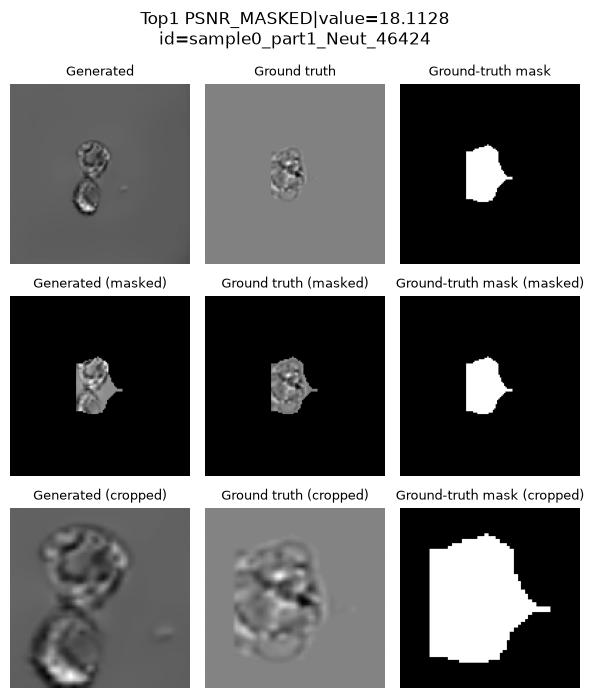

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_Neut_46596,21.92,0.9259,13.41,0.2106,0.0832,0.1501


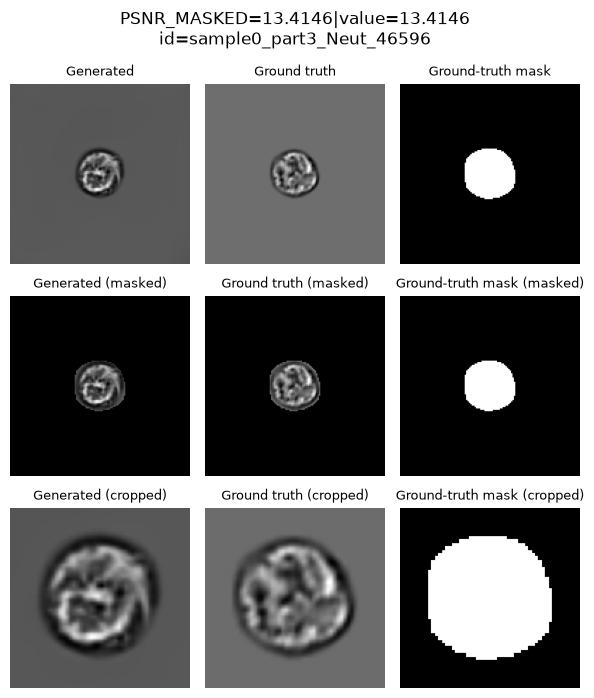

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_B Lymph_30017,6.27,0.6439,5.87,0.0008,0.4731,0.4956


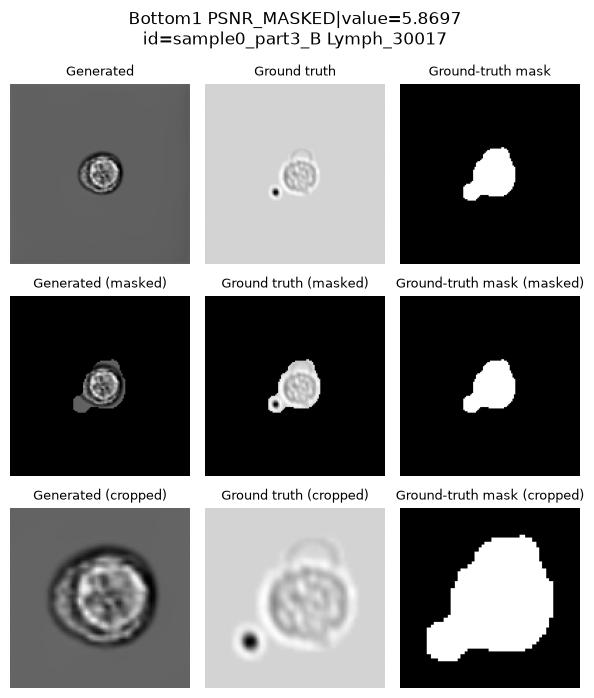

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_B Lymph_36294,29.58,0.9746,16.62,0.6538,0.0529,0.0777


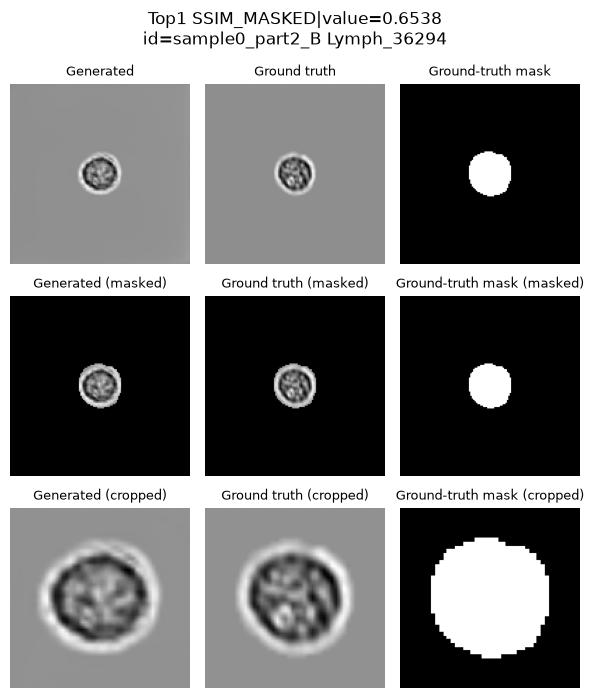

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_Neut_43639,13.46,0.8243,11.09,0.0739,0.2237,0.3358


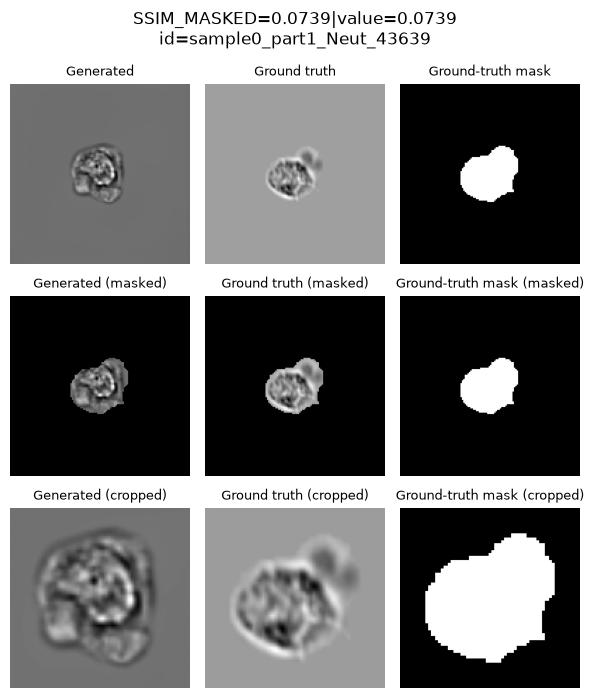

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_T Lymph_19133,17.49,0.8634,7.21,-0.5361,0.1452,0.2279


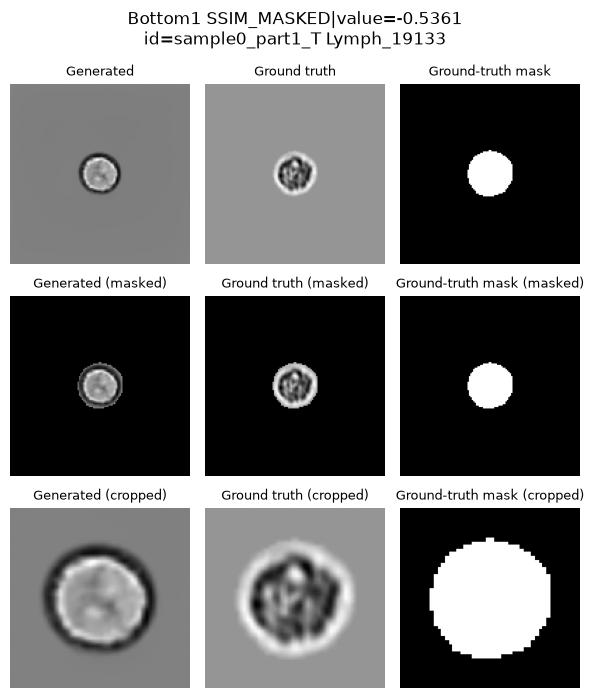

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_Neut_40416,27.65,0.9585,16.51,0.5363,0.0375,0.0758


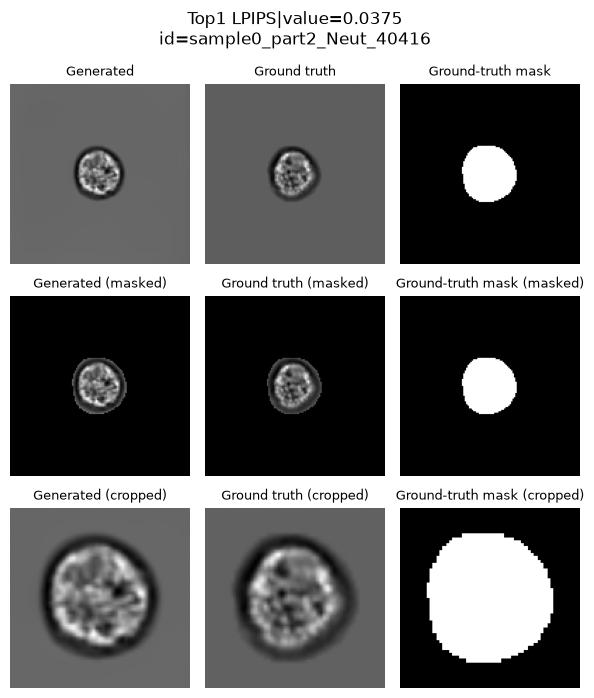

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_Neut_37046,24.83,0.8906,13.42,-0.0579,0.1333,0.2332


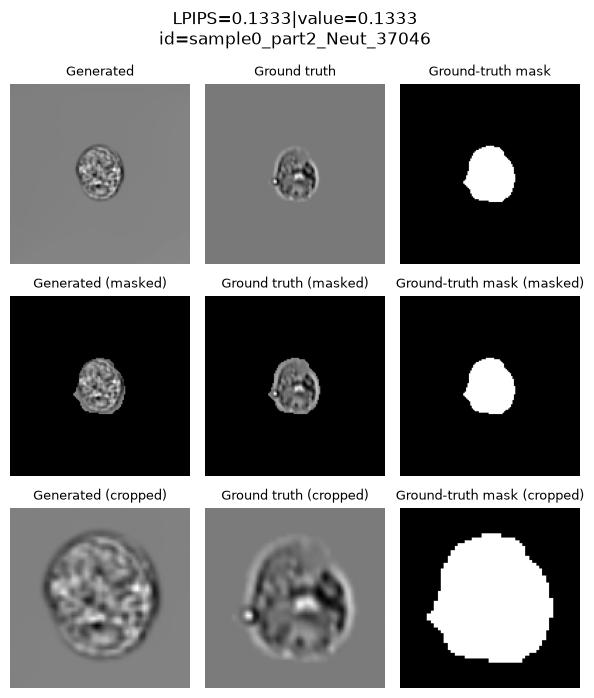

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_6710,7.31,0.6752,6.93,0.0514,0.4988,0.5814


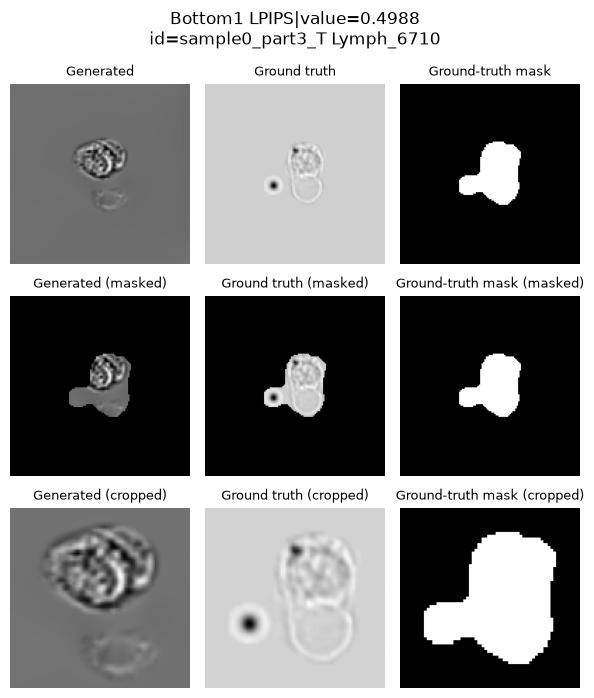

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_Neut_40416,27.65,0.9585,16.51,0.5363,0.0375,0.0758


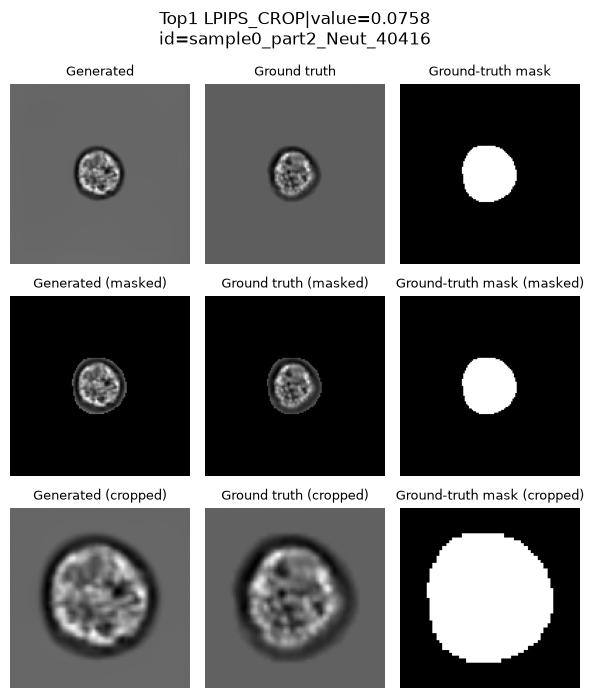

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_T Lymph_32658,18.78,0.8848,14.00,0.0123,0.1174,0.2380


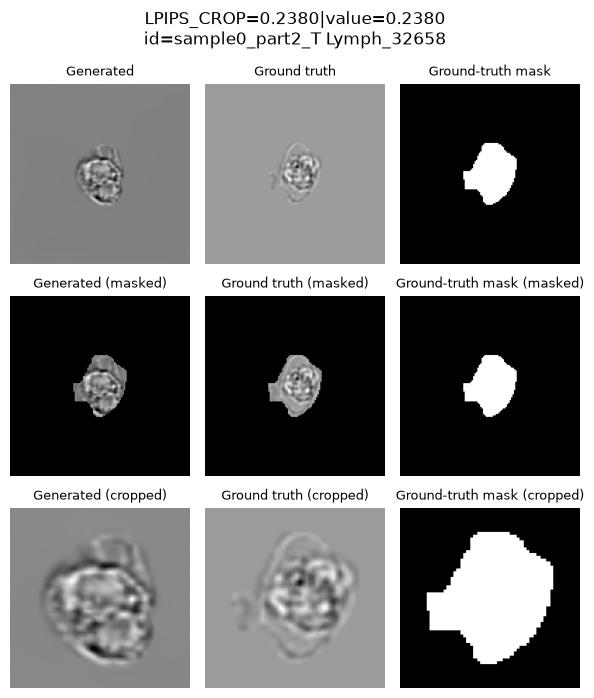

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_6710,7.31,0.6752,6.93,0.0514,0.4988,0.5814


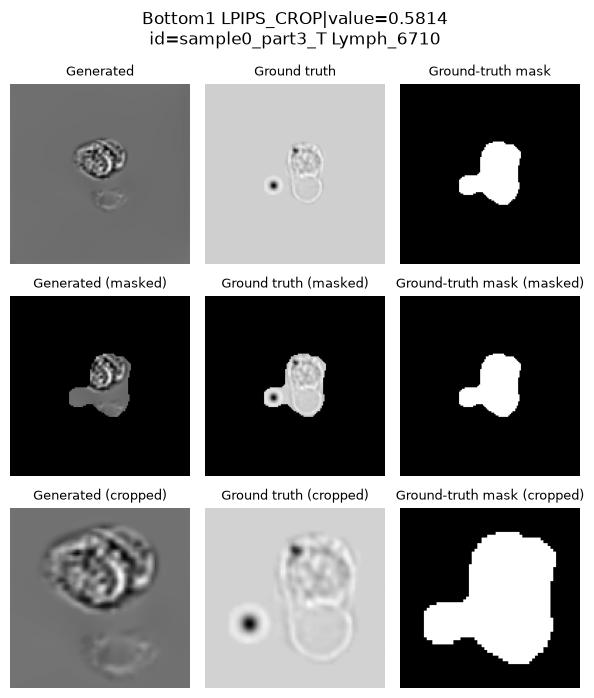

In [26]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("jpg")

from pathlib import Path
ROOT = Path("~/projects/fcmstylegan/experiments/archive/stylegan_baseline_20260819_170800").expanduser()
%run -i plot_test_results.py

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_42773,30.12,0.9657,13.13,0.0849,0.3015,0.3500


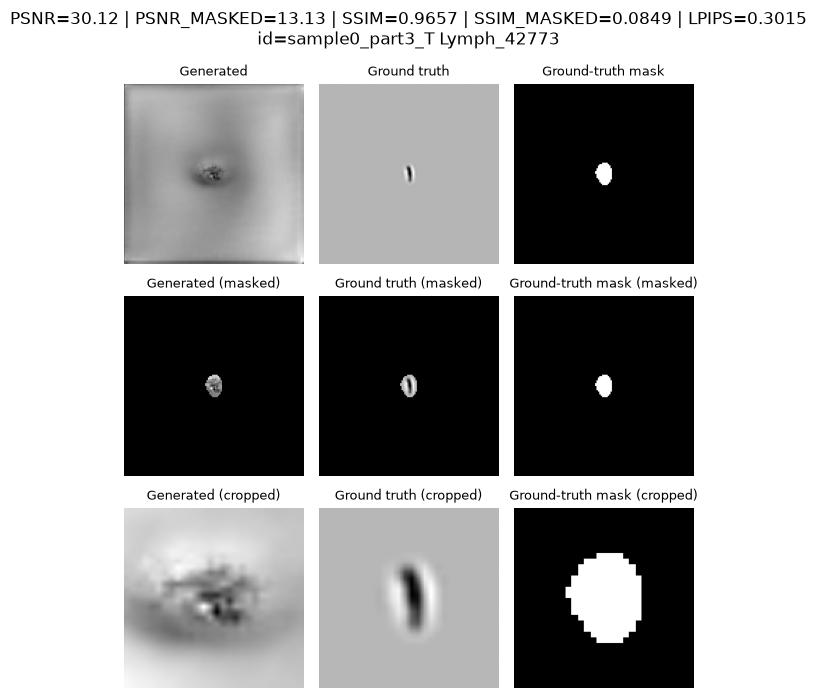

In [27]:


cell_ids = ['sample0_part3_T Lymph_42773']

for cell_id in cell_ids:

    fig, axes = plot_cell(
        cell_id,
        title_metrics= ["psnr", "psnr_masked", "ssim", "ssim_masked", "lpips"]
    )

    axes[0, 0].set_title("My generated image")
    plt.show()

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_B Lymph_14408,14.82,0.8582,10.35,-0.0477,0.1519,0.2181


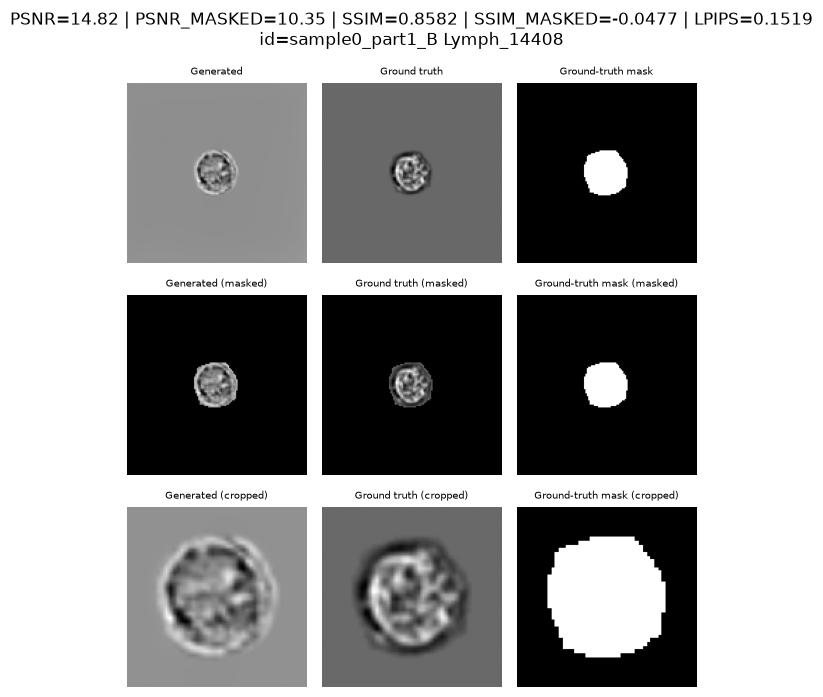

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_Eo_5626,15.97,0.8714,12.18,0.0588,0.1668,0.2226


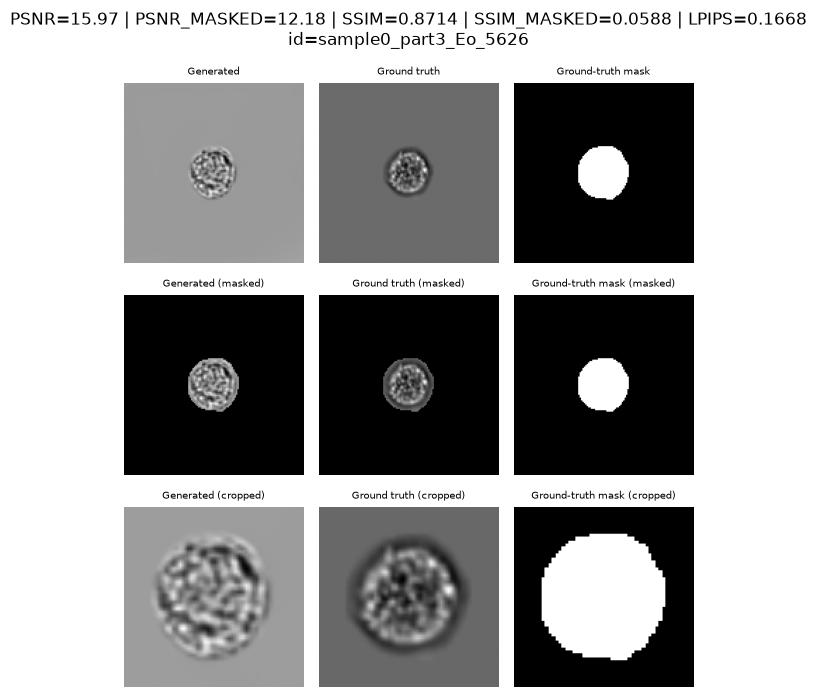

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_Mono_45148,20.98,0.8823,13.20,-0.0455,0.1185,0.2349


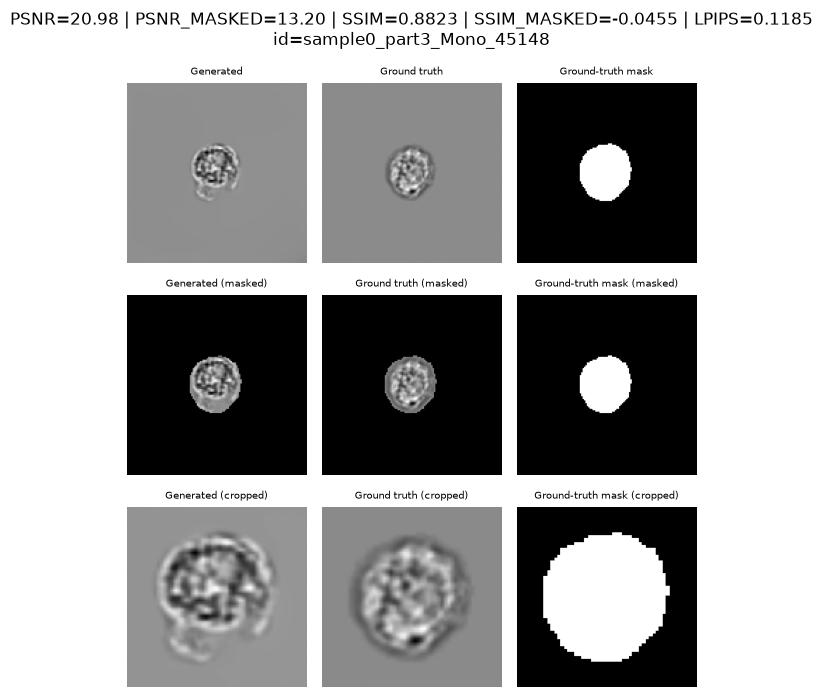

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_Neut_39212,23.29,0.8881,13.84,-0.0231,0.1059,0.1964


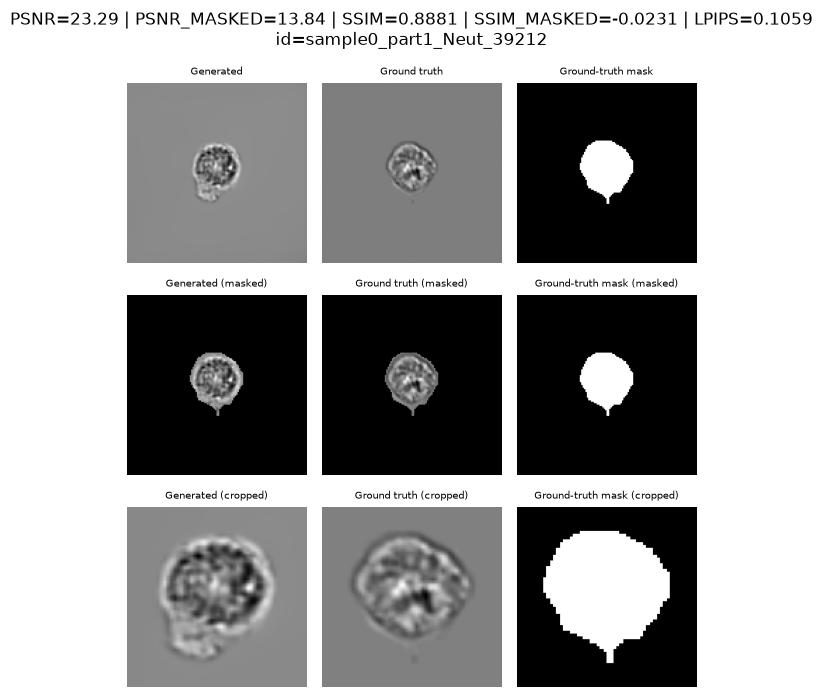

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_T Lymph_34817,15.18,0.8605,11.52,0.0721,0.1657,0.2166


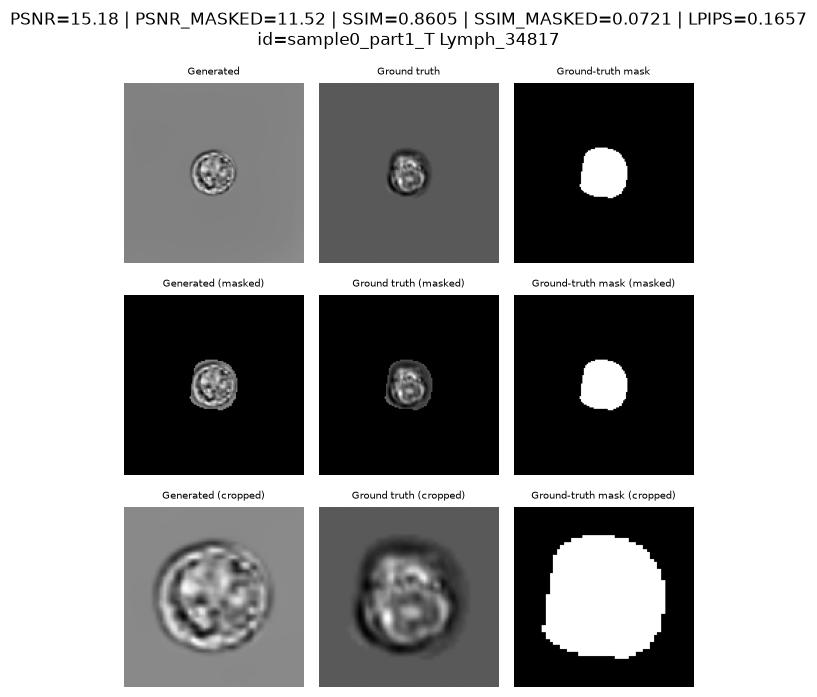

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_24478,9.77,0.7644,9.12,0.1226,0.4245,0.5698


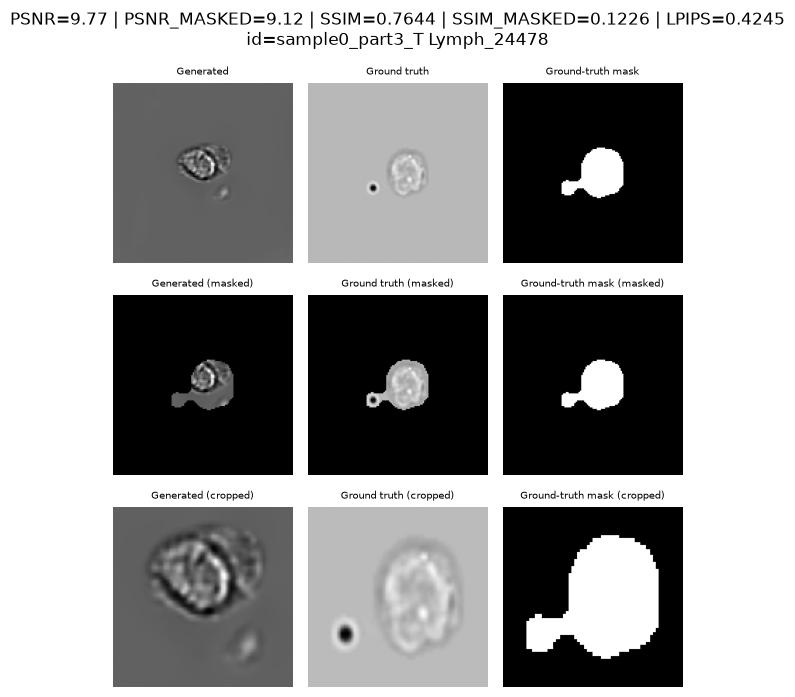

In [25]:
cell_ids = ['sample0_part1_B Lymph_14408',
 'sample0_part3_Eo_5626',
 'sample0_part3_Mono_45148',
 'sample0_part1_Neut_39212',
 'sample0_part1_T Lymph_34817','sample0_part3_T Lymph_24478']

for cell_id in cell_ids:

    fig, axes = plot_cell(
        cell_id,
        title_metrics= ["psnr", "psnr_masked", "ssim", "ssim_masked", "lpips"]
    )

    axes[0, 0].set_title("My generated image")
    plt.show()

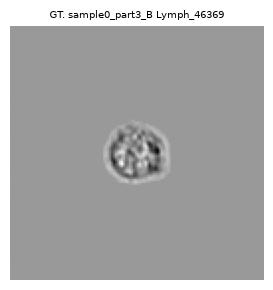

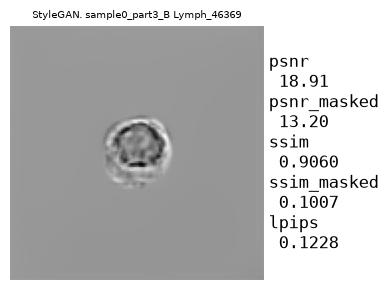

--------------------------------------------------


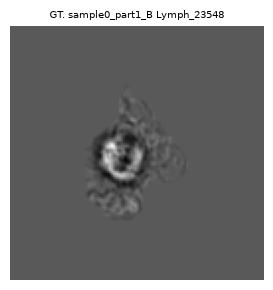

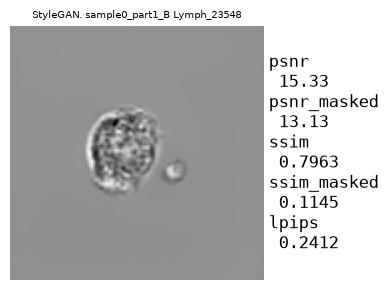

--------------------------------------------------


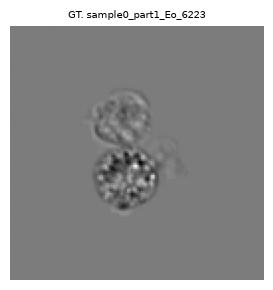

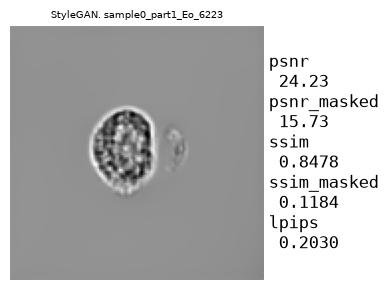

--------------------------------------------------


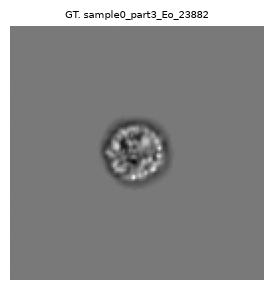

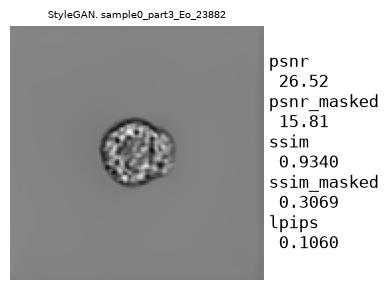

--------------------------------------------------


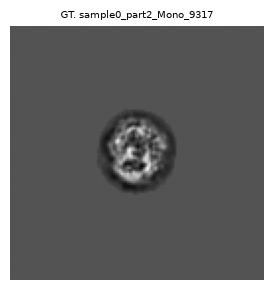

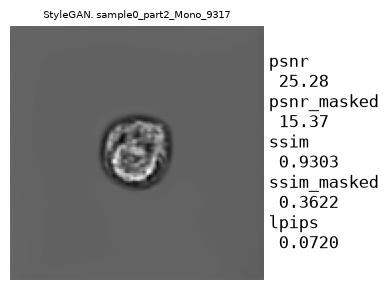

--------------------------------------------------


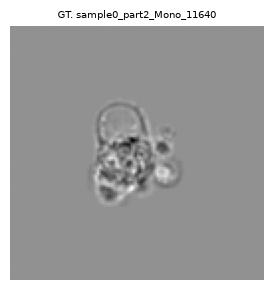

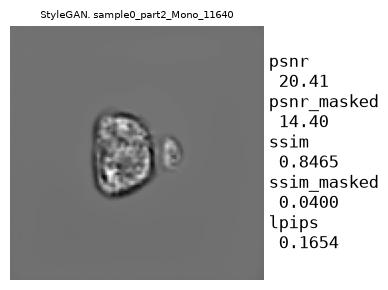

--------------------------------------------------


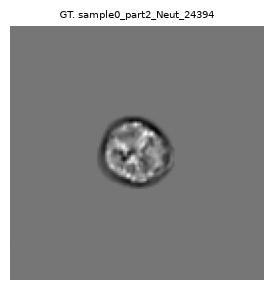

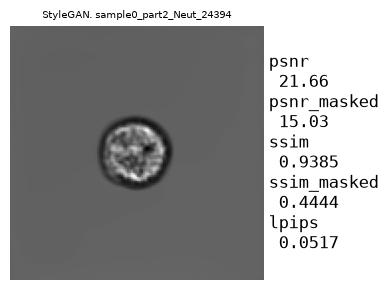

--------------------------------------------------


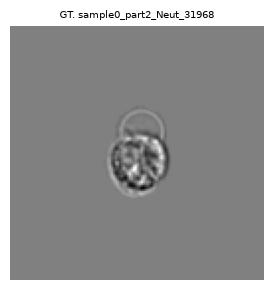

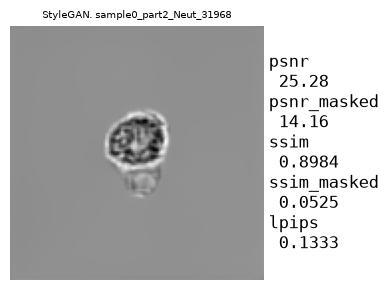

--------------------------------------------------


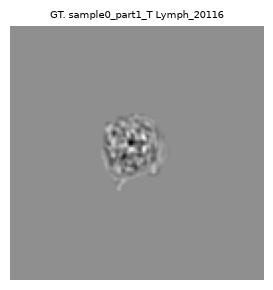

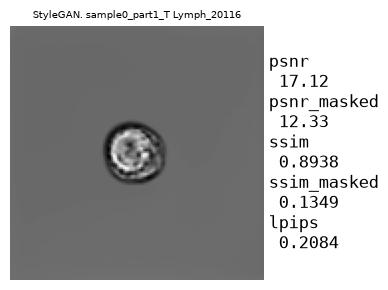

--------------------------------------------------


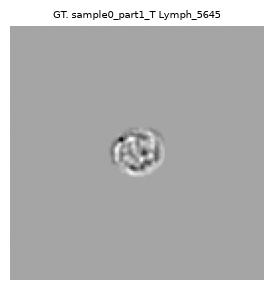

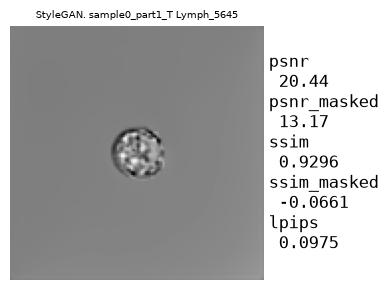

--------------------------------------------------


In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_inline
import matplotlib

matplotlib_inline.backend_inline.set_matplotlib_formats("jpg")
matplotlib.rc("pdf", fonttype=42)

from PIL import Image


# ============================================================
# Placeholder dependencies that need to be defined
# ============================================================
# PREPROCESSED_ROOT = Path("...")
# GENERATED_DIR = Path("...")
# IMAGE_SUFFIX = ".png"
# available_metrics = [...]
# metric_decimals = {}
# df = pd.DataFrame(...)
#
# def safe_id(cell_id): ...
# def crop_to_mask(image, mask_path, resampling): ...


# ============================================================
# Image display helper
# ============================================================

def show_image(
    ax,
    path,
    title,
    mask_path=None,
    cropped=False,
    mask=False,
    masked=False,
):
    ax.axis("off")

    if path.exists():
        # Preserve 16-bit/float image data.
        # Converting to L can wash out GT images.
        image = Image.open(path)

        if cropped:
            image = crop_to_mask(
                image,
                mask_path,
                resampling=(
                    Image.Resampling.NEAREST
                    if mask
                    else Image.Resampling.BILINEAR
                ),
            )

        image_array = np.asarray(image)

        if masked:
            mask_image = (
                Image.open(mask_path)
                .convert("L")
                .resize(image.size, Image.Resampling.NEAREST)
            )

            mask_array = np.asarray(mask_image) > 0

            image_array = np.where(
                mask_array,
                image_array,
                image_array.min(),
            )

        ax.imshow(image_array, cmap="gray")
        ax.set_title(title, fontsize=7)

    else:
        ax.text(
            0.5,
            0.5,
            f"Missing:\n{path}",
            ha="center",
            va="center",
            fontsize=8,
        )


# ============================================================
# Metrics helper
# ============================================================

def _get_metrics_text(sample, metrics):
    """Format specified metrics into a single string."""
    lines = []

    for metric in metrics:
        val = sample[metric]
        decimals = metric_decimals.get(metric, 4)

        formatted_val = (
            f"{val:.{decimals}f}"
            if pd.notna(val)
            else "N/A"
        )

        lines.append(f"{metric}\n {formatted_val}")

    return "\n".join(lines)


# ============================================================
# Ground Truth plot
# ============================================================

def plot_gt(cell_id, figsize=(4, 4)):
    """Create a Ground Truth figure and return (fig, ax)."""

    matches = df[
        df["image_id"].astype(str) == str(cell_id)
    ]

    if matches.empty:
        raise KeyError(f"Cell ID not found: {cell_id}")

    gt_path = (
        PREPROCESSED_ROOT
        / f"{str(cell_id)}{IMAGE_SUFFIX}"
    )

    fig, ax = plt.subplots(figsize=figsize)

    show_image(
        ax,
        gt_path,
        f"GT. {cell_id}",
    )

    plt.tight_layout()

    return fig, ax


# ============================================================
# Generated plot
# ============================================================

def plot_gen(
    cell_id,
    metrics=None,
    figsize=(4, 4),
    fontsize=10,
    model_name="Gen",
):
    """Create a Generated figure and return (fig, ax)."""

    matches = df[
        df["image_id"].astype(str) == str(cell_id)
    ]

    if matches.empty:
        raise KeyError(f"Cell ID not found: {cell_id}")

    sample = matches.iloc[0]

    # Use all available metrics by default
    if metrics is None:
        metrics = available_metrics

    else:
        invalid = [
            m for m in metrics
            if m not in available_metrics
        ]

        if invalid:
            raise ValueError(
                f"Unknown metric(s): {invalid}; "
                f"choose from {available_metrics}"
            )

    generated_path = (
        GENERATED_DIR
        / f"{safe_id(cell_id)}.png"
    )

    fig, ax = plt.subplots(figsize=figsize)

    show_image(
        ax,
        generated_path,
        f"{model_name}. {cell_id}",
    )

    metrics_str = _get_metrics_text(
        sample,
        metrics,
    )

    fig.text(
        1.02,
        0.5,
        metrics_str,
        transform=ax.transAxes,
        fontsize=fontsize,
        verticalalignment="center",
        family="monospace",
    )

    plt.tight_layout()

    return fig, ax


# ============================================================
# Cell IDs
# ============================================================

cell_ids = [
    "sample0_part3_B Lymph_46369",
    "sample0_part1_B Lymph_23548",
    "sample0_part1_Eo_6223",
    "sample0_part3_Eo_23882",
    "sample0_part2_Mono_9317",
    "sample0_part2_Mono_11640",
    "sample0_part2_Neut_24394",
    "sample0_part2_Neut_31968",
    "sample0_part1_T Lymph_20116",
    "sample0_part1_T Lymph_5645",
]


# ============================================================
# Plot configuration
# ============================================================

metrics = [
    "psnr",
    "psnr_masked",
    "ssim",
    "ssim_masked",
    "lpips",
    "lpips_crop",
][:-1]

figsize = (3, 3)
fontsize = 10
model_name = "StyleGAN"


# ============================================================
# Save + show
# ============================================================

for cell_id in cell_ids:

    # --------------------------------------------------------
    # Ground Truth
    # --------------------------------------------------------

    fig, ax = plot_gt(
        cell_id,
        figsize=figsize,
    )

    fig.savefig(
        f"../samplevis/{cell_id}-GT.pdf",
        bbox_inches="tight",
        pad_inches=0,
    )

    plt.show()
    plt.close(fig)


    # --------------------------------------------------------
    # Generated
    # --------------------------------------------------------

    fig, ax = plot_gen(
        cell_id,
        figsize=figsize,
        fontsize=12,
        metrics=metrics,
        model_name=model_name,
    )

    fig.savefig(
        f"../samplevis/{cell_id}-{model_name}.pdf",
        bbox_inches="tight",
        pad_inches=0,
    )

    plt.show()
    plt.close(fig)


    print("-" * 50)


In [24]:
from pathlib import Path
from pypdf import PageObject, PdfReader, PdfWriter

# Configuration
VIS_DIR = Path("../samplevis")
OUTPUT_PDF = VIS_DIR / "combined_comparison.pdf"

# Add or remove models here to dynamically adjust columns
MODELS = ["DCGAN", "StyleGAN"]

cell_ids = [
    "sample0_part3_B Lymph_46369",
    "sample0_part1_B Lymph_23548",
    "sample0_part1_Eo_6223",
    "sample0_part3_Eo_23882",
    "sample0_part2_Mono_9317",
    "sample0_part2_Mono_11640",
    "sample0_part2_Neut_24394",
    "sample0_part2_Neut_31968",
    "sample0_part1_T Lymph_20116",
    "sample0_part1_T Lymph_5645",
]

def load_row_page(cell_id, models, input_dir):
    """Combine GT + Model PDFs horizontally for a single cell_id into an in-memory PageObject."""
    pdf_paths = [input_dir / f"{cell_id}-GT.pdf"] + [
        input_dir / f"{cell_id}-{model}.pdf" for model in models
    ]

    pages = []
    for path in pdf_paths:
        if not path.exists():
            raise FileNotFoundError(f"Missing required PDF: {path}")
        reader = PdfReader(path)
        pages.append(reader.pages[0])

    row_width = sum(float(p.mediabox.width) for p in pages)
    row_height = max(float(p.mediabox.height) for p in pages)

    row_page = PageObject.create_blank_page(width=row_width, height=row_height)

    current_x = 0.0
    for p in pages:
        row_page.merge_translated_page(p, tx=current_x, ty=0.0)
        current_x += float(p.mediabox.width)

    return row_page


def create_comparison_pdf(cell_ids, models, input_dir, output_file, mode="multi_page"):
    """
    Concatenate model PDFs horizontally and cell instances vertically.
    
    Modes:
      - 'multi_page': 1 PDF page per cell_id (multi-page document).
      - 'single_page': All cell_ids stacked vertically onto 1 single long page.
    """
    writer = PdfWriter()
    row_pages = [load_row_page(cid, models, input_dir) for cid in cell_ids]

    if mode == "multi_page":
        for page in row_pages:
            writer.add_page(page)

    elif mode == "single_page":
        total_width = max(float(p.mediabox.width) for p in row_pages)
        total_height = sum(float(p.mediabox.height) for p in row_pages)

        single_long_page = PageObject.create_blank_page(width=total_width, height=total_height)

        # PyPDF origins (0,0) start at the bottom-left corner, 
        # so stack downwards starting from the top.
        current_y = total_height
        for page in row_pages:
            h = float(page.mediabox.height)
            current_y -= h
            single_long_page.merge_translated_page(page, tx=0.0, ty=current_y)

        writer.add_page(single_long_page)

    else:
        raise ValueError(f"Invalid mode: '{mode}'. Use 'multi_page' or 'single_page'.")

    with open(output_file, "wb") as f_out:
        writer.write(f_out)

    print(f"Successfully generated ({mode}) comparison PDF: {output_file}")


if __name__ == "__main__":
    # Modes: "single_page" (all cells stacked vertically) or "multi_page" (1 page per cell)
    create_comparison_pdf(
        cell_ids, 
        MODELS, 
        VIS_DIR, 
        OUTPUT_PDF, 
        mode="single_page"
    )

Successfully generated (single_page) comparison PDF: ../samplevis/combined_comparison.pdf
